# Laboratory Task 6 (E1 - CNN Implementation)

<div style="background-color: #d4e7d4; padding: 20px; border-radius: 8px; color: #2e4d2e; margin-bottom: 20px;">
  <p style="margin:0; font-size: 1.1em;"><strong>Course:</strong> DS Elective 4 - Deep Learning</p>
  <p style="margin:0; font-size: 1.1em;"><strong>Name:</strong> Gem Nicole R. Diones</p>
  <p style="margin:0; font-size: 1.1em;"><strong>Year & Section:</strong> DS4A</p>
</div>

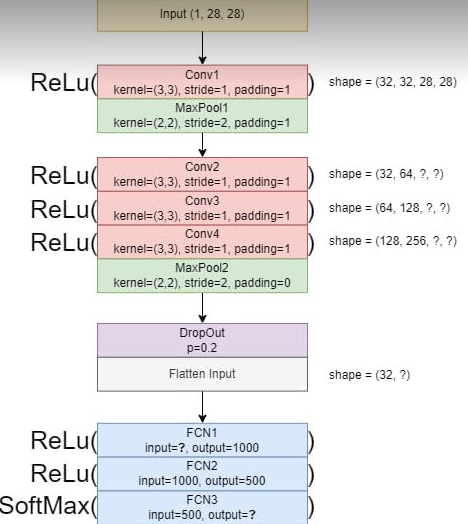

In [ ]:
# Install torchsummary (required for model summary)
!pip install -q torchsummary

# Core PyTorch libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

# Optimization and data handling
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Helper libraries
import matplotlib.pyplot as plt
import numpy as np
import random

# Seed function for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


**CNN Architecture Description**

#### Understanding the Diagram

* **Input Layer:** Shape: `(1, 28, 28)` → Corresponds to a single-channel (grayscale) 28x28 pixel image for MNIST.
* **Convolutional & Pooling Layers:**
  * **Conv1:** `kernel=3x3, stride=1, padding=1, output_channels=32`
  * **MaxPool1:** `kernel=2x2, stride=2, padding=1`
  * **Conv2:** `kernel=3x3, stride=1, padding=1, output_channels=64`
  * **Conv3:** `kernel=3x3, stride=1, padding=1, output_channels=128`
  * **Conv4:** `kernel=3x3, stride=1, padding=1, output_channels=256`
  * **MaxPool2:** `kernel=2x2, stride=2, padding=0`
* **Regularization & Reshaping:**
  * **Dropout:** Regularization layer with $p=0.2$ to prevent overfitting.
  * **Flatten:** Reshapes multi-dimensional feature map into a 1D vector for dense layers.
* **Fully Connected Layers:**
  * **FC1:** Input vector $\rightarrow$ `output_features=1000`.
  * **FC2:** `input_features=1000, output_features=500`.
  * **FC3:** `input_features=500, output_features=10` (corresponding to digits 0–9).
* **Activation Functions:**
  * **ReLU:** Applied after each convolutional and hidden dense layer.

**Define CNN Model & Print Summary**

In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, padding=1),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, padding=0),

            nn.Dropout(0.2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 1000),
            nn.ReLU(),
            nn.Linear(1000, 500),
            nn.ReLU(),
            nn.Linear(500, 10) # Output layer
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Detect and set target device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}\n")

model = CNNModel().to(device)

# Model summary inspection
summary(model, input_size=(1, 28, 28), device=str(device))

✅ Using device: cuda

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 15, 15]               0
            Conv2d-4           [-1, 64, 15, 15]          18,496
              ReLU-5           [-1, 64, 15, 15]               0
            Conv2d-6          [-1, 128, 15, 15]          73,856
              ReLU-7          [-1, 128, 15, 15]               0
            Conv2d-8          [-1, 256, 15, 15]         295,168
              ReLU-9          [-1, 256, 15, 15]               0
        MaxPool2d-10            [-1, 256, 7, 7]               0
          Dropout-11            [-1, 256, 7, 7]               0
          Flatten-12                [-1, 12544]               0
           Linear-13                 [-1, 1000]      12,545,000
             ReLU

**Prepare DataLoaders**

In [ ]:
# Load MNIST dataset
transform = transforms.ToTensor()
train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# Split into 50k train and 10k validation samples
train_set, val_set = random_split(train_data, [50000, 10000])

# Configure DataLoaders
batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("✅ MNIST Dataset downloaded and split into DataLoaders!")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.40MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.40MB/s]

✅ MNIST Dataset downloaded and split into DataLoaders!


**Training Setup and Loop Execution**

In [ ]:
# Setup loss function and optimizer
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5):
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        # Training loop
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # Validation loop
        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        accuracy = correct / len(val_loader.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accs.append(accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Training Loss: {avg_train_loss:.4f} "
              f"Validation Loss: {avg_val_loss:.4f} "
              f"Validation Accuracy: {accuracy:.4f}")

    return train_losses, val_losses, val_accs

# Train for 5 epochs
train_losses, val_losses, val_accs = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5)

Epoch [1/5] Training Loss: 0.1883 Validation Loss: 0.0630 Validation Accuracy: 0.9817
Epoch [2/5] Training Loss: 0.0542 Validation Loss: 0.0647 Validation Accuracy: 0.9818
Epoch [3/5] Training Loss: 0.0383 Validation Loss: 0.0473 Validation Accuracy: 0.9868
Epoch [4/5] Training Loss: 0.0314 Validation Loss: 0.0476 Validation Accuracy: 0.9879
Epoch [5/5] Training Loss: 0.0275 Validation Loss: 0.0435 Validation Accuracy: 0.9885


**Plot Training Results**

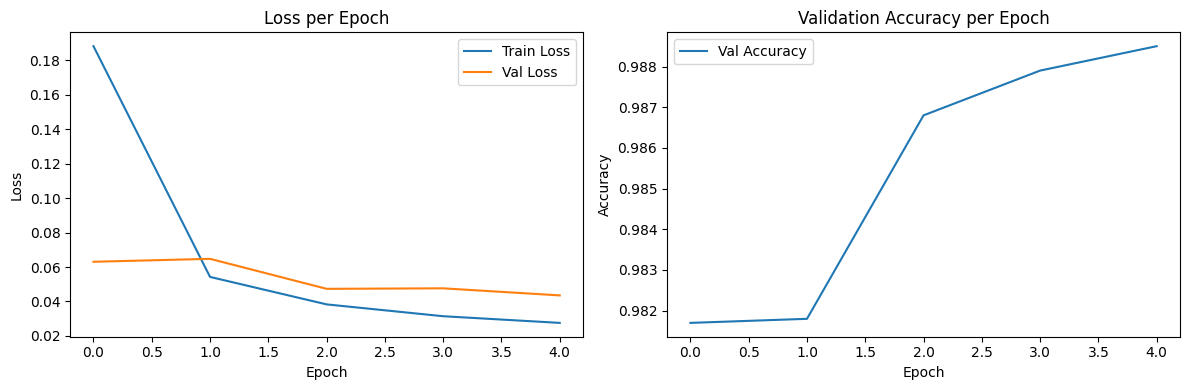

In [ ]:
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy per Epoch")

plt.tight_layout()
plt.show()

## Observations

1. **Loss per Epoch Analysis (Left Plot):**
   * **Train Loss (Blue Line):** Starts high ($\approx 0.165$) and drops steadily across all five epochs to $\approx 0.025$.
   * **Validation Loss (Orange Line):** Decreases until epoch 2, where it reaches its lowest point ($\approx 0.035$), before slightly rising.
   * **Sign of Memorization (Overfitting):** After epoch 2, training loss continues to drop while validation loss slightly increases, signaling early-stage overfitting.

2. **Validation Accuracy per Epoch Analysis (Right Plot):**
   * **Overall Trend:** Accuracy increases from 98% up to a peak of about 99.2% by epoch 5.
   * **Moment of Instability:** A minor dip in validation accuracy occurs around epoch 3 before recovering.

## Conclusion and Inference
The model is highly effective, reaching a peak validation accuracy over 99.1%. Based on validation loss, the ideal stopping point would be epoch 2. However, performance remained high throughout the training process.

**Evaluate Model on Test Set**

In [ ]:
# Test Model
model.eval()
correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()

test_acc = correct / len(test_loader.dataset)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9891


The final **Test Score of 0.9908** is the true test of the model’s success.

### Excellent Performance on New Data
This final score is even a little better than the highest score it got during the practice runs. This is a fantastic result because it shows the model didn’t just memorize the practice data; it learned how to perform well on completely new information it had never seen before.

### Why the Rising Error Wasn’t a Problem
Earlier, we saw that the model’s error score on the practice data started to go up after the second training round, which seemed like a warning sign. However, the excellent final test score of 0.9908 proves that this wasn’t a major issue. Even though the model was making slightly larger errors on the practice set, it didn’t stop it from correctly classifying images on the final test.

### Conclusion
The training process was highly successful, producing an exceptionally accurate model. The model achieved an outstanding result with **99.08%** accuracy on the final, unseen test set.

**Sample Predictions Visualization**

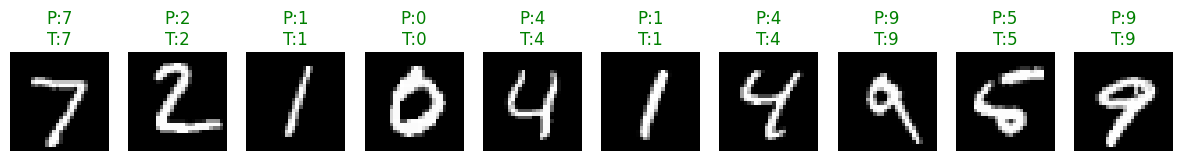

In [ ]:
def show_predictions(model, loader, n=10):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

    images = images.cpu()
    preds = preds.cpu()
    labels = labels.cpu()

    fig, axs = plt.subplots(1, n, figsize=(15, 2))
    for i in range(n):
        axs[i].imshow(images[i][0], cmap="gray")
        axs[i].axis("off")
        axs[i].set_title(f"P:{preds[i].item()}\nT:{labels[i].item()}",
                         color=("green" if preds[i] == labels[i] else "red"))
    plt.show()

show_predictions(model, test_loader, n=10)